In [74]:
from util.benchmark_parser import WorkerBenchmarkParser
from util.encoding import WorkerEncoding
import math

parser = WorkerBenchmarkParser()
encoding = parser.parse_benchmark(r'instances/fjssp-w/3_DPpaulli_1_workers.fjs')

Total operations for job 1: 15
	Options for operation 1 (index 0): 1
		Option 1: Machine 1
			Worker options: 7
				(Worker 1, duration 45)
				(Worker 2, duration 38)
				(Worker 3, duration 42)
				(Worker 4, duration 40)
				(Worker 5, duration 43)
				(Worker 6, duration 42)
				(Worker 7, duration 44)
	Options for operation 2 (index 1): 1
		Option 1: Machine 3
			Worker options: 2
				(Worker 2, duration 62)
				(Worker 5, duration 66)
	Options for operation 3 (index 2): 1
		Option 1: Machine 5
			Worker options: 6
				(Worker 1, duration 22)
				(Worker 2, duration 21)
				(Worker 3, duration 21)
				(Worker 4, duration 24)
				(Worker 5, duration 21)
				(Worker 6, duration 21)
	Options for operation 4 (index 3): 1
		Option 1: Machine 4
			Worker options: 6
				(Worker 1, duration 16)
				(Worker 2, duration 15)
				(Worker 3, duration 17)
				(Worker 4, duration 15)
				(Worker 5, duration 15)
				(Worker 7, duration 17)
	Options for operation 5 (index 4): 3
		Option 1: Machine

In [75]:
from enum import Enum
from dataclasses import dataclass
import random
import util.evaluation as evaluation
import time

class Strategy(Enum):
    PLUS = 1
    COMMA = 2

@dataclass
class Operation:
    machine_index: int
    worker_index: int
    job_index: int
    operation_index: int
    duration: int
    offset: int

class Candidate:
    def __init__(self, schedule: list[list[Operation]], ordered_ops: list[Operation]) -> None:
        self.schedule = schedule
        self.ordered_ops = ordered_ops

        seq, mach, work = self.get_sequences()
        start_times, m_fixed, w_fixed = evaluation.translate(seq, mach, work, encoding.durations())
        self.time = evaluation.makespan(start_times, m_fixed, w_fixed, encoding.durations())

    def __repr__(self) -> str:
        # {[[(task.job_index, task.task_index, task.duration, task.offset) for task in machine] for machine in self.schedule]}
        return f"{self.time}"

    def get_sequences(self) -> tuple[list,list,list]:
        sequence = [op.job_index for op in self.ordered_ops]
        
        total_ops = len(self.ordered_ops)
        machines = [0] * total_ops
        workers = [0] * total_ops
    
        for op in self.ordered_ops:
            machines[op.operation_index] = op.machine_index
            workers[op.operation_index] = op.worker_index

        return sequence, machines, workers

def create_candidate(schedule, machine_ready_times, operation_ready_times, worker_ready_times, ordered_ops, next_op_by_job, last_operation_by_job, active_jobs, encoding: WorkerEncoding) -> Candidate:
    # populate schedule for each machine
    while active_jobs:
        selected_job = random.choice(active_jobs)
        selected_op = next_op_by_job[selected_job]

        # select random viable machine and worker
        usable_machines = encoding.get_machines_for_operation(selected_op)
        selected_machine = random.choice(usable_machines)
        usable_workers = encoding.get_workers_for_operation_on_machine(selected_op, selected_machine)
        selected_worker = random.choice(usable_workers)

        offset = max(operation_ready_times[selected_job], machine_ready_times[selected_machine], worker_ready_times[selected_worker])
        duration = encoding.durations()[selected_op][selected_machine][selected_worker]
        op_info = Operation(selected_machine, selected_worker, selected_job, selected_op, duration, offset)
        schedule[selected_machine].append(op_info)
        ordered_ops.append(op_info)

        operation_ready_times[selected_job] = duration + offset
        machine_ready_times[selected_machine] = duration + offset
        worker_ready_times[selected_worker] = duration + offset

        # check if this was the last task for this job
        next_op_by_job[selected_job] += 1
        if next_op_by_job[selected_job] > last_operation_by_job[selected_job]:
            active_jobs.remove(selected_job)
    
    return Candidate(schedule, ordered_ops)

def get_initial_candidates(m, last_operation_by_job, encoding: WorkerEncoding):
    num_jobs = encoding.n_jobs()
    num_machines = encoding.n_machines()
    num_workers = encoding.n_workers()
    candidates = list[Candidate]()
    for _ in range(m):
        # create a schedule for each machine
        schedule = [list[Operation]() for _ in range(num_machines)]

        # for each machine, store when it becomes available again
        machine_ready_times = [0] * num_machines
        operation_ready_times = [0] * num_jobs
        worker_ready_times = [0] * num_workers

        ordered_ops = []

        # for each job, store the index of the next operation to schedule
        next_operation_by_job = [0] * num_jobs
        operation_index = 0
        for i in range(num_jobs):
            ops_for_current_job = encoding.get_operations_for_job(i)
            next_operation_by_job[i] = operation_index
            operation_index += ops_for_current_job

        # jobs that still have tasks left
        active_jobs = [index for index in range(num_jobs)]
        candidate = create_candidate(schedule, machine_ready_times, operation_ready_times, worker_ready_times, ordered_ops, next_operation_by_job, last_operation_by_job, active_jobs, encoding)
        candidates.append(candidate)
    return candidates

def mutate(parents: list[Candidate], l, last_operation_by_job, encoding: WorkerEncoding) -> list[Candidate]:
    num_jobs = encoding.n_jobs()
    num_machines = encoding.n_machines()
    num_workers = encoding.n_workers()
    children_per_parent = l / len(parents)
    children = list[Candidate]()
    for parent in parents:
        for _ in range(int(children_per_parent)):
            # select random machine and operation to split at
            random_machine_idx = random.randint(0, num_machines - 1)
            operations_for_machine = len(parent.schedule[random_machine_idx])
            random_operation_idx = random.randint(0, operations_for_machine - 1)
            chosen_op = parent.schedule[random_machine_idx][random_operation_idx]

            # reconstruct both the schedule and ordered operations from the ordered sequence
            schedule = [list[Operation]() for _ in range(num_machines)]
            ordered_ops = list[Operation]()
            for op in parent.ordered_ops:
                if op.offset <= chosen_op.offset:
                    ordered_ops.append(op)
                    schedule[op.machine_index].append(op)
                    
                if op == chosen_op:
                    break
            
            # reconstruct state from the partial schedule
            next_operation_by_job = [0] * num_jobs
            op_counter = 0
            for i in range(num_jobs):
                next_operation_by_job[i] = op_counter
                op_counter += encoding.get_operations_for_job(i)
            machine_ready_times = [0] * num_machines
            operation_ready_times = [0] * num_jobs
            worker_ready_times = [0] * num_workers
            
            for op in ordered_ops:
                end_time = op.offset + op.duration
                machine_ready_times[op.machine_index] = end_time
                worker_ready_times[op.worker_index] = end_time
                operation_ready_times[op.job_index] = end_time
                next_operation_by_job[op.job_index] = op.operation_index + 1
            
            # only jobs with remaining tasks are active
            active_jobs = [job_index for job_index in range(num_jobs) if next_operation_by_job[job_index] <= last_operation_by_job[job_index]]
            
            candidate = create_candidate(schedule, machine_ready_times, operation_ready_times, worker_ready_times, ordered_ops, next_operation_by_job, last_operation_by_job, active_jobs, encoding)
            children.append(candidate)
    return children

def solve(strategy: Strategy, m, l, max_generations, encoding: WorkerEncoding) -> tuple[Candidate, list]:
    num_jobs = encoding.n_jobs()
    last_operation_by_job = [0] * num_jobs
    operation_index = 0
    for i in range(num_jobs):
        ops_for_current_job = encoding.get_operations_for_job(i)
        operation_index += ops_for_current_job
        last_operation_by_job[i] = operation_index - 1

    parents = get_initial_candidates(m, last_operation_by_job, encoding)
    offsprings = list[Candidate]()
    history = []
    for gen in range(max_generations):
        offsprings = mutate(parents, l, last_operation_by_job, encoding)

        if strategy == Strategy.PLUS:
            offsprings.extend(parents)
            offsprings.sort(key=lambda x: x.time) 
            parents = []
            for i in range(m):
                parents.append(offsprings[i])
            print(parents)

        elif strategy == Strategy.COMMA:
            offsprings.sort(key=lambda x: x.time) 
            parents = []
            for i in range(m):
                parents.append(offsprings[i])
            print(parents)

        current_best = parents[0].time
        history.append((gen, current_best))

    parents.sort(key=lambda x: x.time) 
    return parents[0], history

In [76]:
best, hist = solve(Strategy.PLUS, 10, 50, 50, encoding)
print("Final best:", best.time)

[4930, 4970, 4985, 5021, 5036, 5044, 5053, 5064, 5108, 5109]
[4837, 4860, 4866, 4890, 4891, 4908, 4930, 4962, 4969, 4970]
[4778, 4790, 4837, 4837, 4851, 4860, 4866, 4876, 4884, 4890]
[4677, 4680, 4778, 4790, 4837, 4837, 4837, 4842, 4847, 4851]
[4677, 4680, 4761, 4772, 4778, 4780, 4790, 4792, 4808, 4837]
[4564, 4677, 4680, 4715, 4722, 4761, 4772, 4778, 4780, 4781]
[4537, 4564, 4594, 4599, 4622, 4633, 4664, 4670, 4677, 4680]
[4523, 4537, 4537, 4564, 4594, 4599, 4604, 4609, 4615, 4622]
[4477, 4503, 4516, 4523, 4537, 4537, 4553, 4564, 4573, 4594]
[4477, 4503, 4516, 4523, 4533, 4537, 4537, 4553, 4558, 4564]
[4473, 4477, 4503, 4503, 4516, 4523, 4533, 4537, 4537, 4553]
[4473, 4477, 4503, 4503, 4504, 4516, 4523, 4527, 4529, 4533]
[4443, 4473, 4477, 4489, 4503, 4503, 4504, 4516, 4523, 4524]
[4443, 4473, 4477, 4484, 4489, 4503, 4503, 4504, 4516, 4523]
[4337, 4443, 4473, 4474, 4477, 4484, 4489, 4493, 4495, 4503]
[4337, 4394, 4443, 4473, 4474, 4477, 4483, 4484, 4489, 4492]
[4337, 4338, 4394, 4443,

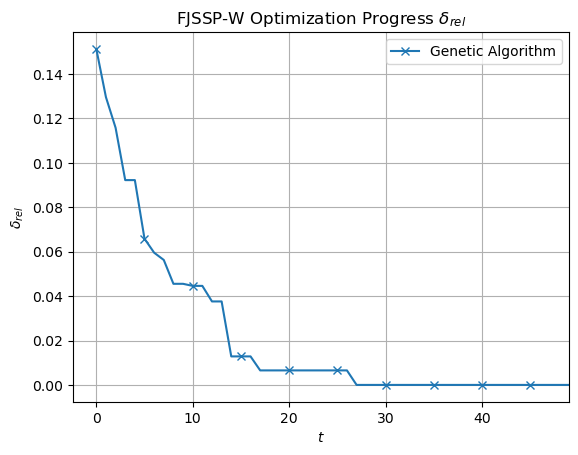

In [77]:
from util import visualization
plot_data = {"Genetic Algorithm": hist}
visualization.visualize_timeline(plot_data, title="FJSSP-W Optimization Progress")